Training features shape: (60000, 784)
Testing features shape: (10000, 784)

--- Training model using: SGD with Momentum ---
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8947 - loss: 0.3801 - val_accuracy: 0.9341 - val_loss: 0.2238
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9452 - loss: 0.1953 - val_accuracy: 0.9533 - val_loss: 0.1605
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9592 - loss: 0.1459 - val_accuracy: 0.9621 - val_loss: 0.1298
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9664 - loss: 0.1175 - val_accuracy: 0.9668 - val_loss: 0.1122
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9720 - loss: 0.0988 - val_accuracy: 0.9701 - val_loss: 0.1012
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9761 - loss: 0.0851 - val_accuracy: 0.9721 - val_loss: 0.0939
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9793 - loss: 0.0746 - val_accuracy: 0.9743

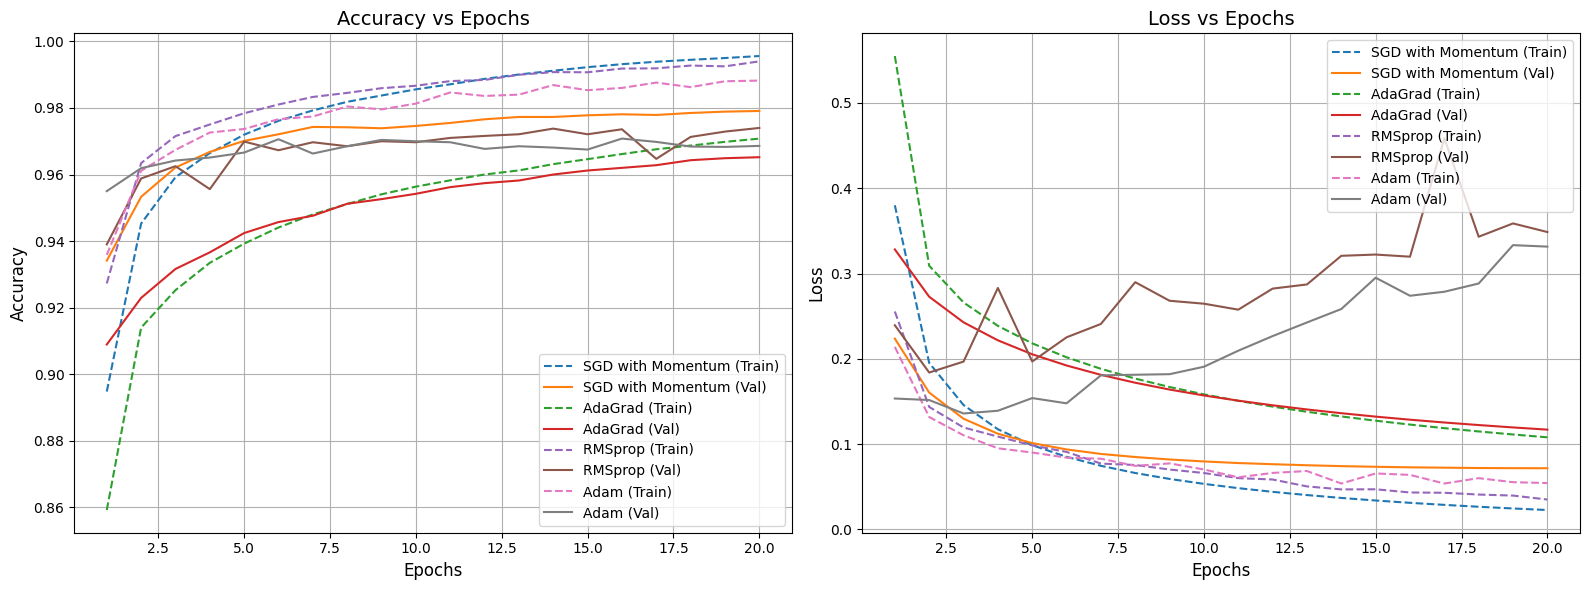

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# I. LOAD & PREPROCESS DATASET
# Using tf.keras.datasets.mnist for built-in compatibility:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Reshape image inputs from (28, 28) matrices to 1D vectors of 784 features
X_train = X_train_raw.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test_raw.reshape(-1, 28 * 28).astype("float32") / 255.0

# Convert labels to 1D integer arrays 
y_train = y_train_raw
y_test = y_test_raw

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# II. DESIGN NEURAL NETWORK ARCHITECTURE
def build_model():
    """
    Constructs a simple 1-hidden-layer neural network:
    - Input layer: 784 neurons
    - Hidden layer: 128 neurons, ReLU activation
    - Output layer: 10 neurons, Softmax activation
    """
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu', name='hidden_layer'),
        layers.Dense(10, activation='softmax', name='output_layer')
    ])
    return model

# III & IV. SETUP OPTIMIZERS & FIXED HYPERPARAMETERS
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# Dictionary of optimizers (Keeping learning rate constant at 0.01)
optimizer_dict = {
    'SGD with Momentum': optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.9),
    'AdaGrad': optimizers.Adagrad(learning_rate=LEARNING_RATE),
    'RMSprop': optimizers.RMSprop(learning_rate=LEARNING_RATE),
    'Adam': optimizers.Adam(learning_rate=LEARNING_RATE)
}

history_dict = {}

# Train model separately for each optimizer
for opt_name, opt_instance in optimizer_dict.items():
    print(f"\n--- Training model using: {opt_name} ---")
    
    tf.random.set_seed(42)
    model = build_model()
    
    model.compile(
        optimizer=opt_instance,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Fit model and record training history
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    
    history_dict[opt_name] = history.history

# V. COMPARE METRICS & PERFORMANCE
comparison_data = []

for opt_name, hist in history_dict.items():
    final_tr_acc = hist['accuracy'][-1]
    final_val_acc = hist['val_accuracy'][-1]
    final_tr_loss = hist['loss'][-1]
    final_val_loss = hist['val_loss'][-1]
    
    comparison_data.append({
        'Optimizer': opt_name,
        'Train Loss': f"{final_tr_loss:.4f}",
        'Val Loss': f"{final_val_loss:.4f}",
        'Train Acc': f"{final_tr_acc * 100:.2f}%",
        'Val Acc': f"{final_val_acc * 100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Final Performance Comparison (After 20 Epochs) ===")
print(comparison_df.to_string(index=False))

# VI. PLOT ACCURACY & LOSS VS EPOCHS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, EPOCHS + 1)

# Plot 1: Accuracy vs Epochs
for opt_name, hist in history_dict.items():
    axes[0].plot(epochs_range, hist['accuracy'], label=f"{opt_name} (Train)", linestyle='--')
    axes[0].plot(epochs_range, hist['val_accuracy'], label=f"{opt_name} (Val)", linestyle='-')

axes[0].set_title('Accuracy vs Epochs', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Plot 2: Loss vs Epochs
for opt_name, hist in history_dict.items():
    axes[1].plot(epochs_range, hist['loss'], label=f"{opt_name} (Train)", linestyle='--')
    axes[1].plot(epochs_range, hist['val_loss'], label=f"{opt_name} (Val)", linestyle='-')

axes[1].set_title('Loss vs Epochs', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

'''
CONVERGENCE ANALYSIS & JUSTIFICATION

Which converged fastest?
Adam and RMSprop reached high accuracy the fastest in the first few epochs, 
but SGD with Momentum was the fastest to reach a stable, optimal minimum.

Why this happened:

1. Adam & RMSprop :
   These methods calculate individual learning rates for every weight based on 
   recent gradients. This lets them take massive, fast strides early on. 
   However, keeping the base learning rate at 0.01 was too aggressive for them 
   later in training. Once they got close to the minimum, the step sizes stayed 
   too large, causing them to overshoot and bounce around (explaining the high val loss).

2. SGD with Momentum :
   Momentum keeps a running average of past gradient directions—like giving 
   the optimizer physical momentum. It cancels out side-to-side zig-zagging and 
   accelerates straight down the slope. At a 0.01 learning rate, it smoothly 
   guided the weights right into a clean minimum without overshooting.

3. AdaGrad :
   AdaGrad adds up ALL past squared gradients from step 1 in its denominator. 
   Because that number only grows bigger, the effective learning rate shrinks 
   too fast, making the model "freeze" before it could finish learning properly.
'''